In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
import pickle
import nue_booster
import importlib
importlib.reload(nue_booster)
import awkward
from typing import List, Tuple, Any, Union
from numpy.typing import NDArray
import hashlib
import logging
import os
import yaml
from numu_tki import selection_1muNp 
from numu_tki import signal_1muNp 
from numu_tki import tki_calculators 

import localSettings as ls

import sys, os 
from data_loading import load_runs

from microfit.selections import get_selection_query

In [3]:
# split_type = 'simple'
split_type = 'mc_query'
# split_type = 'mc_nue_query'

In [4]:
# RUN = ["4a_nuepresel","4b_nuepresel","4c_nuepresel","4d_nuepresel","5_nuepresel"]
RUN = ["4a_zppresel","4b_zppresel","4c_zppresel","4d_zppresel","5_zppresel"]

# Use truth filters for 'simple' split
if split_type == 'simple':
    rundata, mc_weights, data_pot = load_runs(
        RUN,
        data="bnb",
        truth_filtered_sets=["nue", "drt", "nc_pi0"],
        use_truth_filters=True,
        loadpi0variables=True,
        loadshowervariables=True, # Loads in all variables we might want, including BDT variables (use_bdt=True asserts that these variables are loaded)
        loadrecoveryvars=True,
        loadsystematics=False,    # Set to false when we don't have event weights
        load_crt_vars=True,
        loadnumuvariables=True,
        use_bdt = False,          # Set use_BDT to false since we are training the BDT here, not using it
        use_numi=False,
        load_lee=False,
        enable_cache=True,
        blinded=True,             # Set blinded to true, no training on data!!
    )

# Don't use truth filters for query split
if split_type == 'mc_query' or split_type == 'mc_nue_query':
    rundata, mc_weights, data_pot = load_runs(
        RUN,
        data="bnb",
        truth_filtered_sets=["nue", "drt", "nc_pi0"],
        use_truth_filters=False,
        loadpi0variables=True,
        loadshowervariables=True, # Loads in all variables we might want, including BDT variables (use_bdt=True asserts that these variables are loaded)
        loadrecoveryvars=True,
        loadsystematics=False,    # Set to false when we don't have event weights
        load_crt_vars=True,
        loadnumuvariables=True,
        use_bdt = False,          # Set use_BDT to false since we are training the BDT here, not using it
        use_numi=False,
        load_lee=False,
        enable_cache=True,
        blinded=True,             # Set blinded to true, no training on data!!
    )

Loading run 4a_zppresel
Loading run 4b_zppresel
Loading run 4c_zppresel
Loading run 4d_zppresel
Loading run 5_zppresel


In [5]:
df_nu=rundata["mc"]
df_nue=rundata["nue"]
df_dirt=rundata["drt"]
df_ncpi0=rundata["nc_pi0"]
df_ext=rundata["ext"]

In [6]:
# Split dataframes into training and testing samples according to split_type
if split_type == 'simple':
    train_nu, test_nu = train_test_split(df_nu, test_size=0.5, random_state=1990)
    train_nue, test_nue = train_test_split(df_nue, test_size=0.5, random_state=1990)
    train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
    train_ncpi0, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
    train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

# if split_type == 'mc_query':
#     train_nue_truth, test_nue = train_test_split(df_nue, test_size=0.5, random_state=1990)
#     train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
#     train_ncpi0_truth, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
#     train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

if split_type == 'mc_query':
    train_nue_truth, test_nue = train_test_split(df_nue, test_size=0.75, random_state=1990)
    train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.75, random_state=1990)
    train_ncpi0_truth, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.75, random_state=1990)
    train_ext, test_ext = train_test_split(df_ext, test_size=0.75, random_state=1990)

# if split_type == 'mc_nue_query':
#     train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
#     train_ncpi0_truth, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
#     train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

if split_type == 'mc_nue_query':
    train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.75, random_state=1990)
    train_ncpi0_truth, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.75, random_state=1990)
    train_ext, test_ext = train_test_split(df_ext, test_size=0.75, random_state=1990)

In [7]:
# For either type of query, separate double counted truth events
# if split_type == 'mc_query' or split_type == 'mc_nue_query':
#     # Separate CC Nue events from nu overlay
#     NUEQUERY = '(abs(nu_pdg)==12 & ccnc==0)'
#     nu_ccnue = df_nu.query(NUEQUERY)

#     # Separate NC Pi0 events from nu overlay
#     NCPI0QUERY = '(mcf_pass_ncpi0==1)'
#     nu_ncpi0 = df_nu.query(NCPI0QUERY)

#     # Get sample that doesn't have CC Nue or NC Pi0 events (basically take the opposite of the previous two queries combined)
#     MCQUERY = '((abs(nu_pdg)==12 & ccnc==0) | mcf_pass_ncpi0==1)'
#     nu_no_ccnue_ncpi0 = df_nu.query('~'+MCQUERY)

#     # Split this new nu overlay sample into training and testing samples
#     train_nu, test_nu = train_test_split(nu_no_ccnue_ncpi0, test_size=0.5, random_state=1990)

#     # Add the nu overlay NC pi0 events to the NC pi0 training sample
#     train_ncpi0 = pd.concat([train_ncpi0_truth, nu_ncpi0], ignore_index=True)

if split_type == 'mc_query' or split_type == 'mc_nue_query':
    # Separate CC Nue events from nu overlay
    NUEQUERY = '(abs(nu_pdg)==12 & ccnc==0)'
    nu_ccnue = df_nu.query(NUEQUERY)

    # Separate NC Pi0 events from nu overlay
    NCPI0QUERY = '(mcf_pass_ncpi0==1)'
    nu_ncpi0 = df_nu.query(NCPI0QUERY)

    # Get sample that doesn't have CC Nue or NC Pi0 events (basically take the opposite of the previous two queries combined)
    MCQUERY = '((abs(nu_pdg)==12 & ccnc==0) | mcf_pass_ncpi0==1)'
    nu_no_ccnue_ncpi0 = df_nu.query('~'+MCQUERY)

    # Split this new nu overlay sample into training and testing samples
    train_nu, test_nu = train_test_split(nu_no_ccnue_ncpi0, test_size=0.75, random_state=1990)

    # Add the nu overlay NC pi0 events to the NC pi0 training sample
    train_ncpi0 = pd.concat([train_ncpi0_truth, nu_ncpi0], ignore_index=True)
    
# For MC query split only, add the nu overlay CC nue events to the nue truth training sample
if split_type == 'mc_query':
    train_nue = pd.concat([train_nue_truth, nu_ccnue], ignore_index=True)

In [8]:
if split_type == 'mc_nue_query':
    ZPQUERY = 'category==10'
    NPQUERY = 'category==11'
    NUEOTHERQUERY = '(category!=10 & category!=11)'

    # Split nue overlay into three different nue categories
    zp_nue = df_nue.query(ZPQUERY)
    np_nue = df_nue.query(NPQUERY)
    other_nue = df_nue.query(NUEOTHERQUERY)

    # Split nu overlay CC nue samples into different nue categories 
    zp_nu_ccnue = nu_ccnue.query(ZPQUERY)
    np_nu_ccnue = nu_ccnue.query(NPQUERY)
    other_nu_ccnue = nu_ccnue.query(NUEOTHERQUERY)

    # Choose signal definition
    nue_signal = 'ZP'
    # nue_signal = 'ZP_NP'

    if nue_signal == 'ZP':
        # Define signal and background nue samples
        signal_nue = zp_nue
        bkg_nue = pd.concat([np_nue, other_nue], ignore_index=True)

        # Define signal and background nue events from nu overlay sample
        signal_nu_ccnue = zp_nu_ccnue
        bkg_nu_ccnue = pd.concat([np_nu_ccnue, other_nu_ccnue], ignore_index=True)

    if nue_signal == 'ZP_NP':
        signal_nue = pd.concat([zp_nue, np_nue], ignore_index=True)
        bkg_nue = other_nue

        signal_nu_ccnue = pd.concat([zp_nu_ccnue, np_nu_ccnue])
        bkg_nu_ccnue = other_nu_ccnue

    # Split signal and background nue samples
    # train_signal_df_nue, test_signal_nue = train_test_split(signal_nue, test_size=0.5, random_state=1990)
    # train_bkg_df_nue, test_bkg_nue = train_test_split(bkg_nue, test_size=0.5, random_state=1990)

    train_signal_df_nue, test_signal_nue = train_test_split(signal_nue, test_size=0.75, random_state=1990)
    train_bkg_df_nue, test_bkg_nue = train_test_split(bkg_nue, test_size=0.75, random_state=1990)

    # Concatenate nu overlay CC nue events into their respective nue overlay training samples
    train_signal_nue = pd.concat([train_signal_df_nue, signal_nu_ccnue], ignore_index=True)
    train_bkg_nue = pd.concat([train_bkg_df_nue, bkg_nu_ccnue], ignore_index=True)

In [9]:
if split_type == 'mc_nue_query':
    samples = {
        "mc": (train_nu, test_nu),
        "nue_signal": (train_signal_nue, test_signal_nue),
        "nue_bkg": (train_bkg_nue, test_bkg_nue),
        "dirt": (train_dirt, test_dirt),
        "ncpi0": (train_ncpi0, test_ncpi0),
        "ext": (train_ext, test_ext),
    }

if split_type == 'simple' or split_type == 'mc_query':
    samples = {
        "mc": (train_nu, test_nu),
        "nue": (train_nue, test_nue),
        "dirt": (train_dirt, test_dirt),
        "ncpi0": (train_ncpi0, test_ncpi0),
        "ext": (train_ext, test_ext),
    }

In [10]:
# Set weights for training samples
for k, df in samples.items():
    df[0].loc[:,"train_weight"] = 1.
    df[1].loc[:,"train_weight"] = 1.

# override here train_weight for specific samples, if needed
# QUESTION: are there more specific weights we need here?
samples['ext'][0].loc[:,"train_weight"] = 10.
samples['ext'][1].loc[:,"train_weight"] = 10.

# Set train weight for a specific category (find out what category 4 is)
for k, df in samples.items():
    df[0].loc[df[0]['category']==4,"train_weight"] = 10.
    df[1].loc[df[1]['category']==4,"train_weight"] = 10.

# set train_weight based on reco_e binning
# reco_bins = np.linspace(0.15,1.55,15)
# #reco_scaling = [8,5,3,3,2,2,2,1,1,1,1,1,1,1]
# reco_scaling = [1,1,1,1,1,1,1,1,1,1,1,1,1,1]
# for k, df in samples.items():
#     for i, reco_bin in enumerate(reco_bins):
#         if i == 0: continue
#         df[0].loc[(df[0]['reco_e'] > reco_bins[i-1]) & (df[0]['reco_e'] < reco_bins[i]), 'train_weight'] = df[0]['train_weight']*reco_scaling[i-1]

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`


In [11]:
# Inclusive set of variables w/ NuGraph
TRAINVAR = [
    "shrmoliereavg",
    "shr_score",
    "trkfit",
    "subcluster",
    "CosmicIPAll3D",
    "CosmicDirAll3D",
    "shrMCSMom",
    "DeltaRMS2h",
    "shrPCA1CMed_5cm",
    "CylFrac2h_1cm",    
    "shr_tkfit_2cm_dedx_Y",
    "shr_tkfit_2cm_dedx_U",
    "shr_tkfit_2cm_dedx_V",
    "shr_tkfit_gap10_dedx_Y",
    "shr_tkfit_gap10_dedx_U",
    "shr_tkfit_gap10_dedx_V",
    "shr_tkfit_dedx_max",
    "secondshower_U_nhit",
    "secondshower_U_vtxdist",
    "secondshower_U_dot",
    "secondshower_U_dir",
    "anglediff_U",
    "secondshower_V_nhit",
    "secondshower_V_vtxdist",
    "secondshower_V_dot",
    "secondshower_V_dir",
    "anglediff_V",
    "secondshower_Y_nhit",
    "secondshower_Y_vtxdist",
    "secondshower_Y_dot",
    "secondshower_Y_dir",
    "anglediff_Y",
    "slcng2mip",
    "slcng2hip",
    "slcng2shr",
    "slcng2mcl",
    "slcng2dfs",
    "slcng2bkg",
    "clung2mip",
    "clung2hip",
    "clung2shr",
    "clung2mcl",
    "clung2dfs",
    "clung2bkg",
    "nhits_r1cm",
    "nhits_r3cm",
    "nhits_r5cm",
    "nhits_r10cm",
    "diffY","normdiffY","diffZ","normdiffZ","fnl",
    "is_signal","train_weight","nu_e"
]

# Np Training Variables
# TRAINVAR = [
#     "shr_score",
#     "tksh_distance",
#     "tksh_angle",
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "trkfit",
#     "trkpid",
#     "subcluster",
#     "shrmoliereavg",
#     "trkshrhitdist2",
#     "hits_ratio",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "slcng2mip",
#     "slcng2hip",
#     "slcng2shr",
#     "slcng2mcl",
#     "slcng2dfs",
#     "slcng2bkg",
#     "clung2mip",
#     "clung2hip",
#     "clung2shr",
#     "clung2mcl",
#     "clung2dfs",
#     "clung2bkg",
#     "nhits_r1cm",
#     "nhits_r3cm",
#     "nhits_r5cm",
#     "nhits_r10cm",
#     "diffY","normdiffY","diffZ","normdiffZ","fnl",
#     "is_signal","train_weight","nu_e"
# ]

In [12]:
# print (ls.pickle_path)

XGBoost params. ETA: 0.02, MAX_DEPTH: 3, SUBSAMPLE: 0.8, COLSAMPLE_BY_TREE: 1
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl', 'is_signa

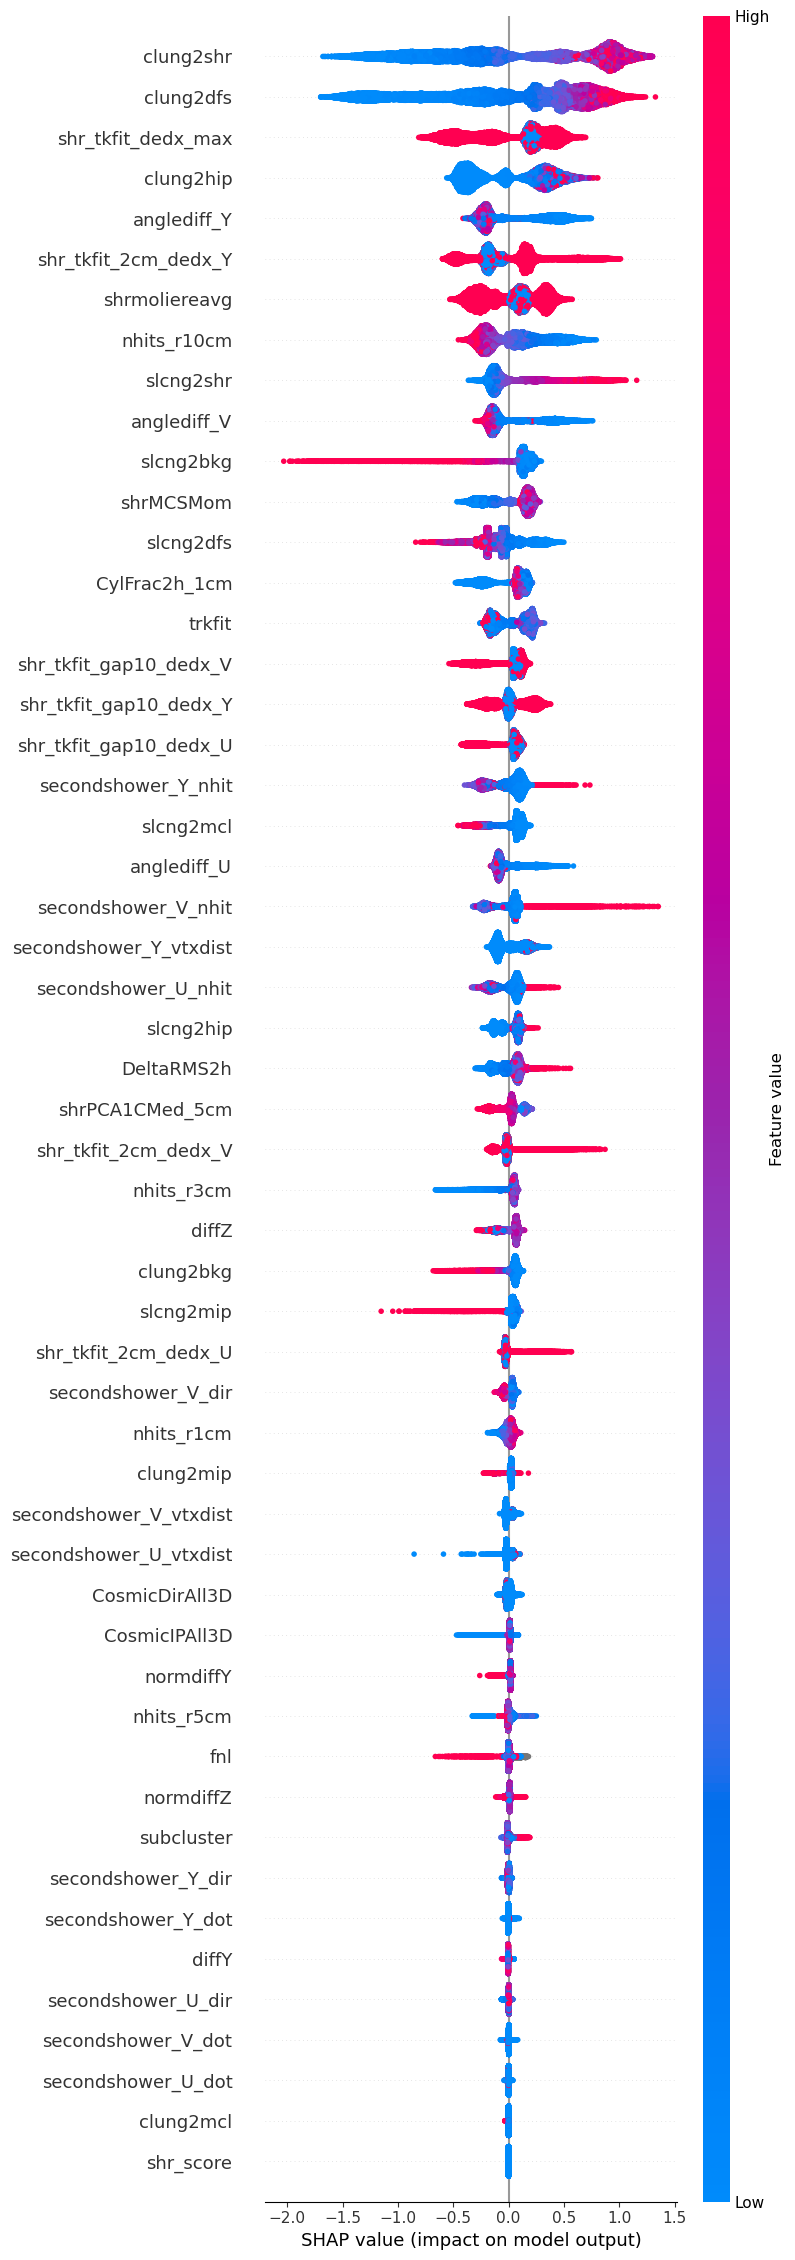

area under the precision-recall curve: 0.952310
precision score: 0.903797
recall score: 0.841054
Importance (total_gain):
clung2shr 200105.27825102003
clung2dfs 56721.32767736994
slcng2bkg 55391.57061818003
anglediff_Y 38786.73321172003
clung2hip 37633.074901589986
shr_tkfit_dedx_max 34850.48073141998
shrMCSMom 31834.763728830014
shr_tkfit_2cm_dedx_Y 31213.787421710003
shrmoliereavg 30594.346509009993
anglediff_V 19044.746355550003
nhits_r10cm 16279.412132649997
shr_tkfit_gap10_dedx_Y 14746.16763730999
slcng2shr 14199.672466680004
slcng2mip 11808.366640460003
secondshower_V_nhit 10436.69813541001
CylFrac2h_1cm 10418.5849891
slcng2mcl 9968.210284619996
secondshower_Y_nhit 9185.300371940004
slcng2dfs 8585.475519200001
trkfit 7787.166953731997
secondshower_Y_vtxdist 7535.259460010003
clung2bkg 7483.694929169998
anglediff_U 7287.683674841003
shr_tkfit_gap10_dedx_V 7229.892340020002
secondshower_U_nhit 6421.2416277421025
DeltaRMS2h 5507.485220759997
shr_tkfit_2cm_dedx_V 5436.894880969999
sh

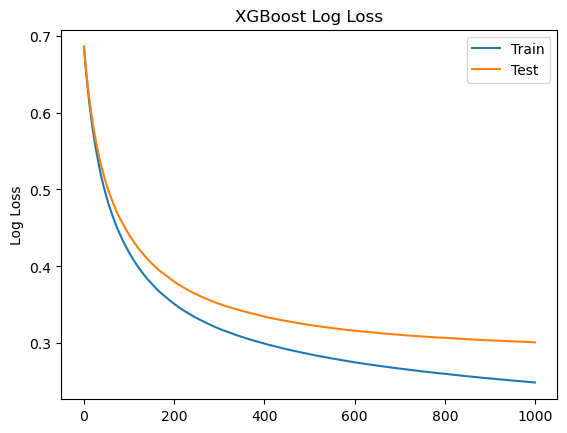

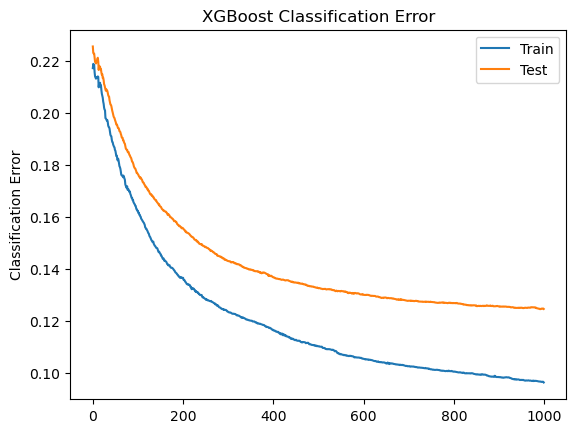

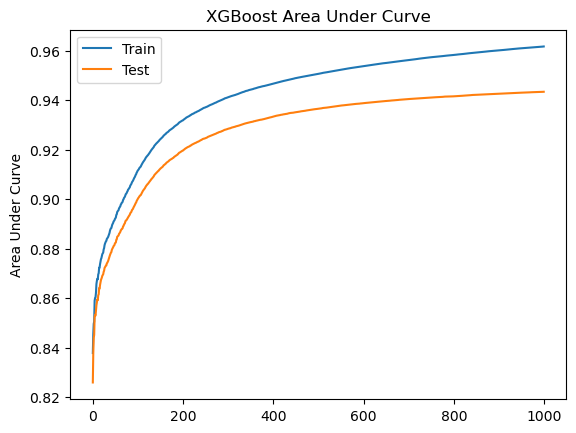

Training pi0...
&category!=10 and category!=11 and npi0>0
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl']
Validating...


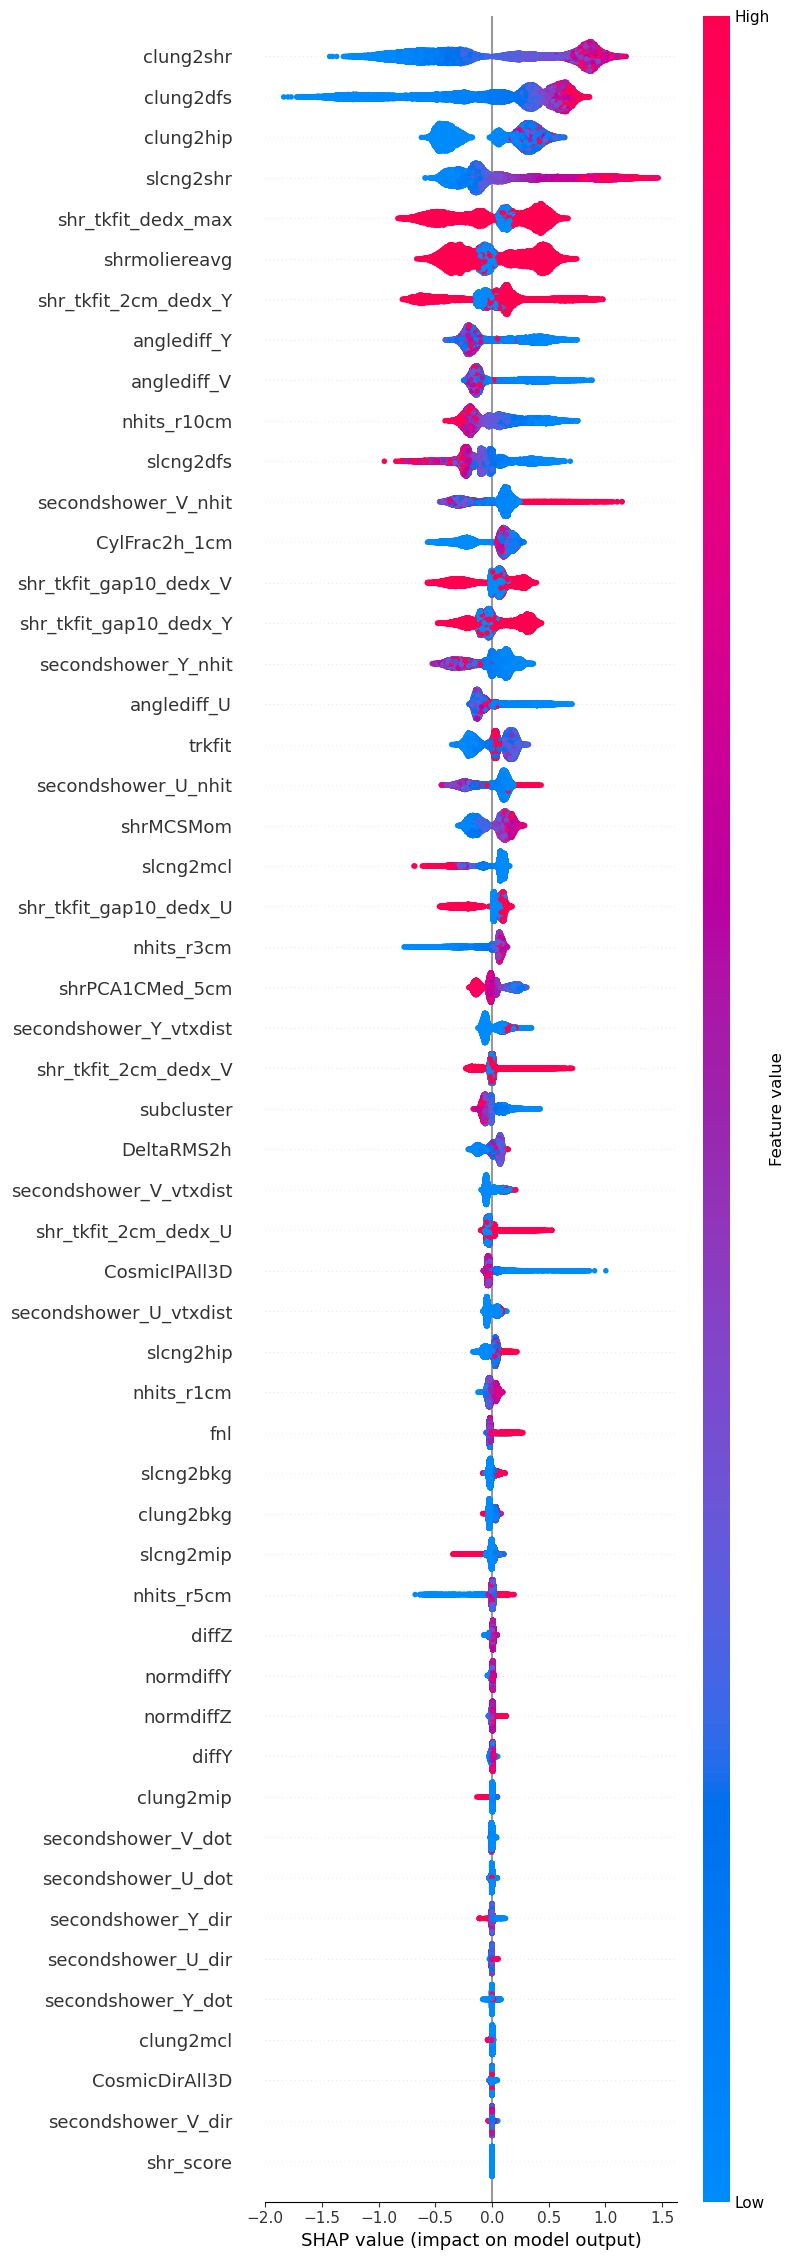

area under the precision-recall curve: 0.960536
precision score: 0.901998
recall score: 0.876884
Importance (total_gain):
clung2shr 154938.55966244507
clung2dfs 39450.88734942003
shr_tkfit_dedx_max 36536.72072651997
clung2hip 34615.87078264
shrmoliereavg 33812.09178278002
slcng2shr 28778.00367647999
shr_tkfit_2cm_dedx_Y 27738.80225837
anglediff_Y 24763.162703069993
shr_tkfit_gap10_dedx_Y 20490.427695139988
anglediff_V 17069.28708142001
secondshower_V_nhit 16704.822093589995
shrMCSMom 14092.352592249998
secondshower_Y_nhit 12875.59940360001
slcng2dfs 11307.818602389989
CylFrac2h_1cm 11067.509923569998
shr_tkfit_gap10_dedx_V 9655.245428639995
anglediff_U 9379.506157186994
secondshower_U_nhit 9283.634574460002
nhits_r10cm 8795.234540841
slcng2mcl 5392.292934060002
trkfit 5002.804195172998
shr_tkfit_2cm_dedx_V 4520.234934209999
nhits_r3cm 4053.4915013399996
shr_tkfit_gap10_dedx_U 3611.146294829999
secondshower_Y_vtxdist 3402.8835215299996
shrPCA1CMed_5cm 3153.32269777
shr_tkfit_2cm_dedx_U 

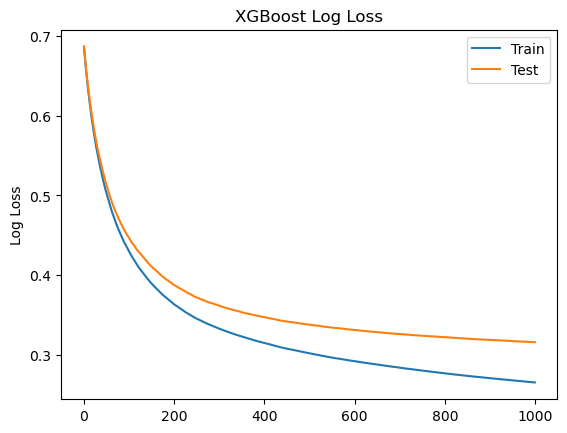

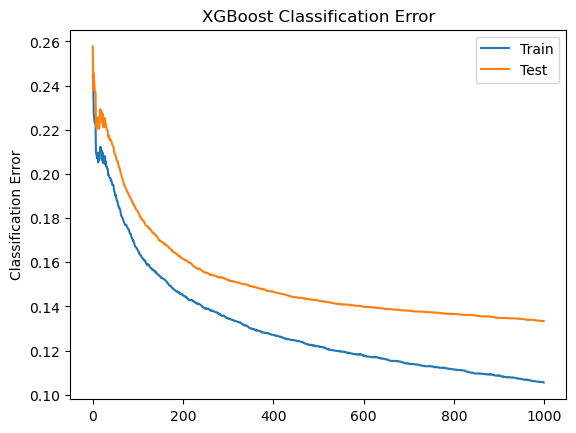

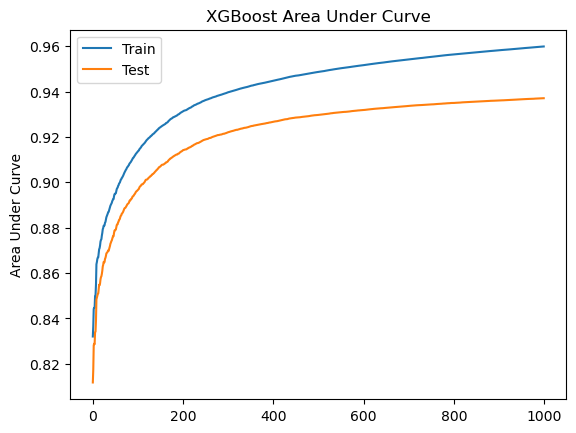

Training nonpi0...
&category!=10 and category!=11 and npi0==0
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl']
Validating...


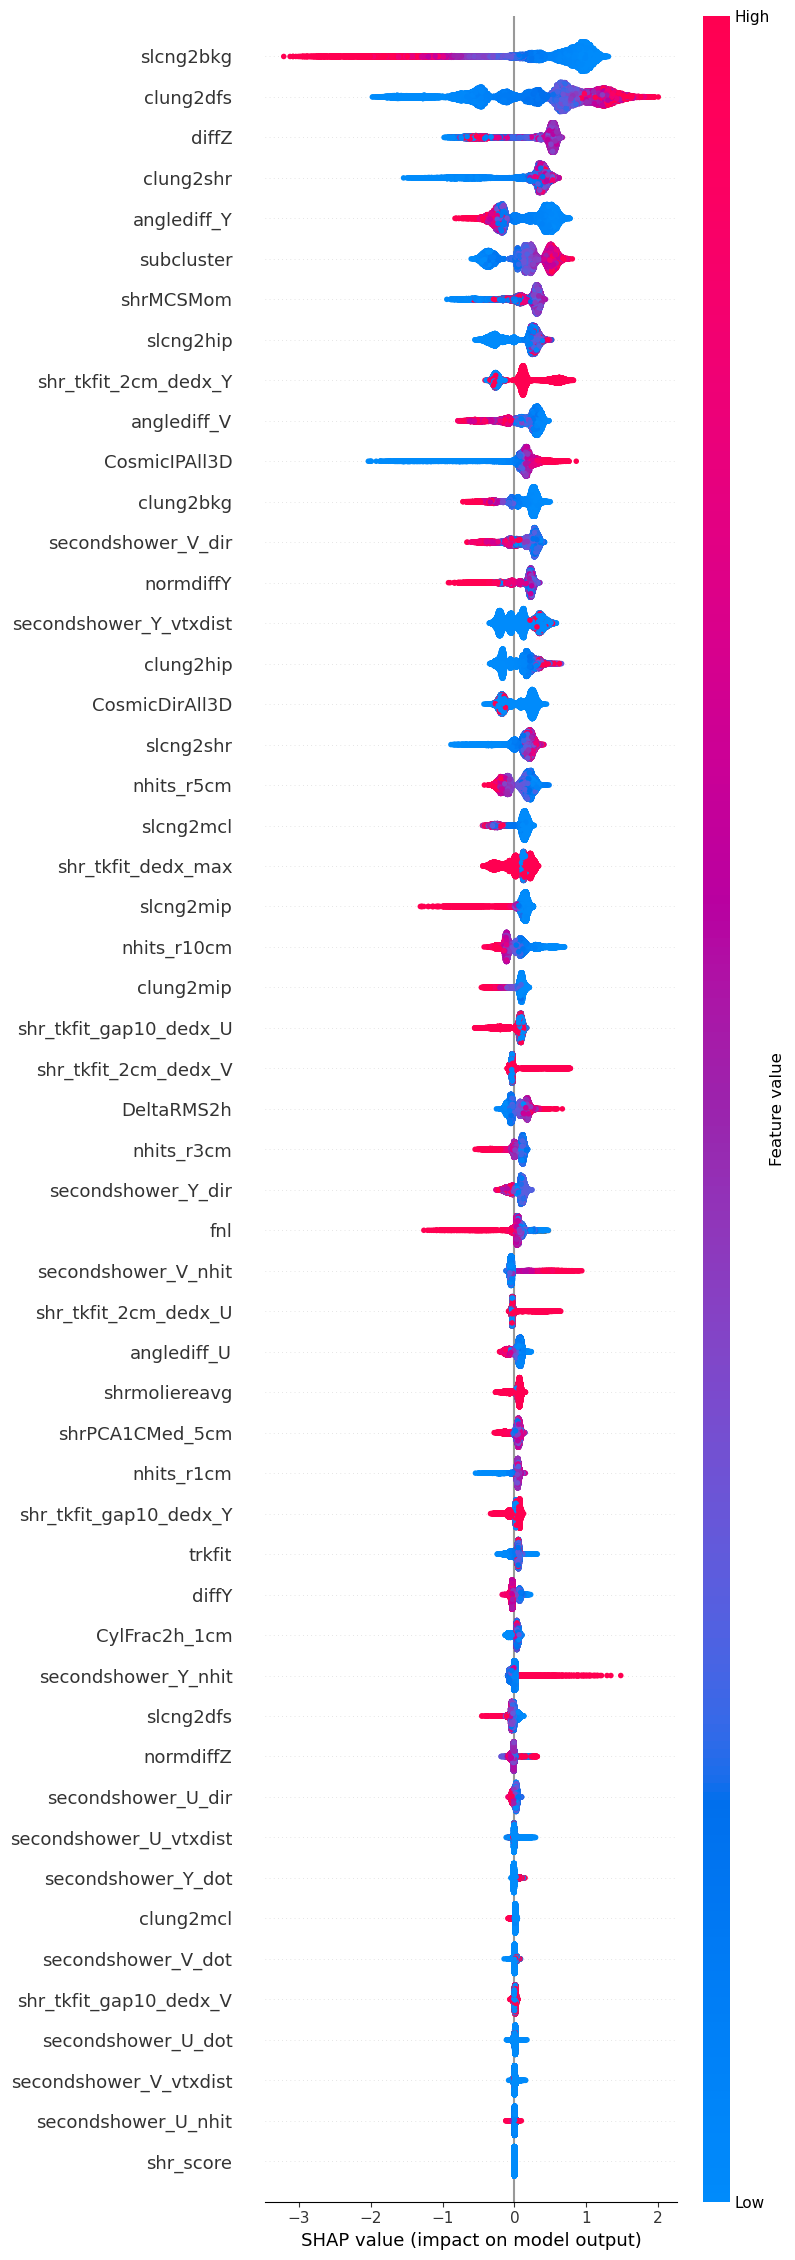

area under the precision-recall curve: 0.997284
precision score: 0.981219
recall score: 0.969755
Importance (total_gain):
slcng2bkg 148619.3111188639
clung2shr 105951.33093760008
clung2dfs 47942.01054832437
subcluster 40324.691138315015
shrMCSMom 33201.550259759
anglediff_Y 24650.052937490014
diffZ 22434.489782725006
CosmicIPAll3D 20606.453007890992
slcng2shr 15155.589267630008
secondshower_V_dir 14207.085605920005
slcng2mip 14052.897846208996
clung2hip 12782.9908245042
slcng2hip 11767.59047842
anglediff_V 10848.334286000001
normdiffY 9408.932591099996
clung2bkg 8996.028587419998
secondshower_Y_vtxdist 8237.89418731
nhits_r5cm 7706.9016295400015
shr_tkfit_2cm_dedx_Y 7338.574514429996
CosmicDirAll3D 6679.231567499996
fnl 5995.211801959996
nhits_r10cm 5663.351095809998
slcng2mcl 4983.326064360001
DeltaRMS2h 4676.5499565779
shr_tkfit_dedx_max 4304.84751341
nhits_r3cm 4103.559528380001
shrmoliereavg 3733.670018939999
shr_tkfit_gap10_dedx_U 3637.0093070200005
secondshower_Y_dir 3186.3298084

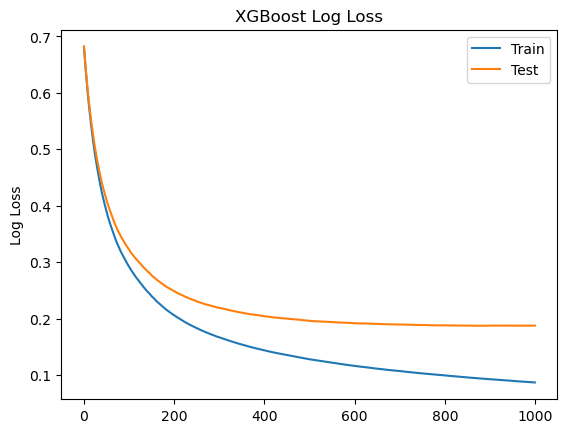

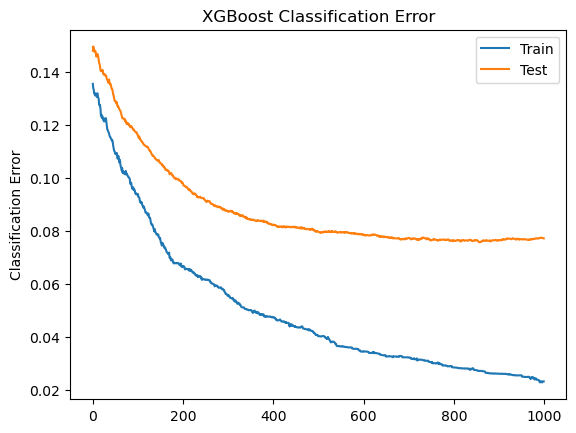

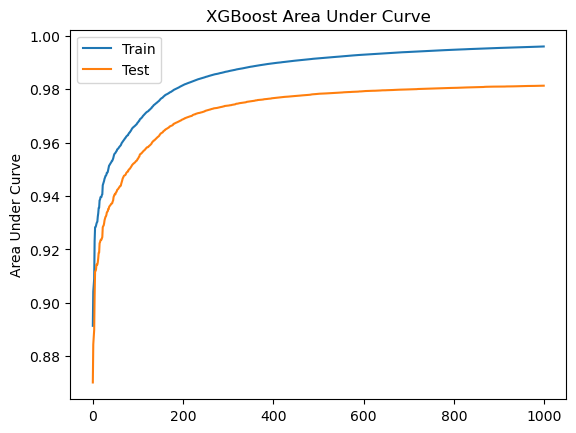

In [13]:
fig, ax = plt.subplots(1,1)

importlib.reload(nue_booster)
my_booster = nue_booster.NueBooster(samples, TRAINVAR, random_state=1990)

print (my_booster.variables)

# Nue Preselection
# PRESEL = 'slice_orig_pass_id == 1'
# PRESEL += ' and n_showers_contained == 1'
# PRESEL += ' and contained_fraction > 0.9'
# PRESEL += ' and shr_energy_tot_cali > 0.07'
# PRESEL += ' and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'

# Extra Cosmic Rejection
# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and trkfit < 0.65'

PRESEL = '( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'
PRESEL += ' and n_tracks_contained == 0'

PRESEL += ' and crtveto != 1'

# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and shrmoliereavg < 20'
# PRESEL += ' and subcluster > 5'
# PRESEL += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 100'
# PRESEL += ' and shr_trk_len > 20'
# PRESEL += ' and CylFrac2h_1cm < 0.7'
# PRESEL += ' and shrMCSMom > 20'
# PRESEL += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'

# PRESEL += ' and diffZ > -70 and diffZ < 80'
# PRESEL += ' and normdiffZ > -0.75 and normdiffZ < 0.75'
# PRESEL += ' and fnl > -200 and fnl < 50'

# PRESEL += ' and nonpi0_score > 0.9'
# PRESEL += ' and pi0_score > 0.5'

# PRESEL += ' and slcng2hip < 40'
# PRESEL += ' and slcng2mip < 50'
# PRESEL += ' and slcng2mcl < 40'
# PRESEL += ' and clung2hip < 50'

# Old Loose Sel.
# PRESEL = '( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'
# PRESEL += ' and n_tracks_contained == 0'
# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and CosmicDirAll3D > -0.9 and CosmicDirAll3D < 0.9'
# PRESEL += ' and shrmoliereavg < 15'
# PRESEL += ' and subcluster > 4'
# PRESEL += ' and trkfit < 0.65'
# PRESEL += ' and secondshower_Y_nhit < 50'
# PRESEL += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 80'
# PRESEL += ' and shr_trk_sce_end_y > -100 and shr_trk_sce_end_y < 100 '
# PRESEL += ' and shr_trk_len < 300.'
# PRESEL += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'

my_booster.set_preselection(PRESEL)

gain_imp = {}

for label, bkg_query in zip(nue_booster.labels, nue_booster.bkg_queries):
    
    preds, gain_imp[label], evals_result, shap_values = my_booster.train_booster(ax, bkg_query)
    
    with open(ls.pickle_path+'booster_%s_45_1011_zppresel_mcquery_75split.pickle' % label, 'wb') as booster_file:
        pickle.dump(preds, booster_file)

    #print(evals_result)
    epochs = len(evals_result['train']['error'])
    x_axis = range(0, epochs)
    # plot log loss
    fig1, ax1 = plt.subplots()
    ax1.plot(x_axis, evals_result['train']['logloss'], label='Train')
    ax1.plot(x_axis, evals_result['eval']['logloss'], label='Test')
    ax1.legend()
    plt.ylabel('Log Loss')
    plt.title('XGBoost Log Loss')
    plt.show()
    # plot classification error
    fig2, ax2 = plt.subplots()
    ax2.plot(x_axis, evals_result['train']['error'], label='Train')
    ax2.plot(x_axis, evals_result['eval']['error'], label='Test')
    ax2.legend()
    plt.ylabel('Classification Error')
    plt.title('XGBoost Classification Error')
    plt.show()
    # plot auc
    fig3, ax3 = plt.subplots()
    ax3.plot(x_axis, evals_result['train']['auc'], label='Train')
    ax3.plot(x_axis, evals_result['eval']['auc'], label='Test')
    ax3.legend()
    plt.ylabel('Area Under Curve')
    plt.title('XGBoost Area Under Curve')
    plt.show()

    
ax.set_ylim([0, 1.05])
ax.set_xlim([0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC')
ax.legend()
fig.tight_layout()
#fig.savefig(ls.plots_path+"roc_single.pdf")

In [14]:
if split_type == 'simple' or split_type == 'mc_query':
    print('mc',train_nu.query(PRESEL)["train_weight"].sum())
    print('nue',train_nue.query(PRESEL)["train_weight"].sum())
    print('dirt',train_dirt.query(PRESEL)["train_weight"].sum())
    print('ncpi0',train_ncpi0.query(PRESEL)["train_weight"].sum())
    print('ext',train_ext.query(PRESEL)["train_weight"].sum())

if split_type == 'mc_nue_query':
    print('mc',train_nu.query(PRESEL)["train_weight"].sum())
    print('nue_signal',train_signal_nue.query(PRESEL)["train_weight"].sum())
    print('nue_bkg',train_bkg_nue.query(PRESEL)["train_weight"].sum())
    print('dirt',train_dirt.query(PRESEL)["train_weight"].sum())
    print('ncpi0',train_ncpi0.query(PRESEL)["train_weight"].sum())
    print('ext',train_ext.query(PRESEL)["train_weight"].sum())

mc 1441.0
nue 23484.0
dirt 95.0
ncpi0 14902.0
ext 8950.0


In [15]:
if split_type == 'simple' or split_type == 'mc_query':
    print('mc',test_nu.query(PRESEL)["train_weight"].sum())
    print('nue',test_nue.query(PRESEL)["train_weight"].sum())
    print('dirt',test_dirt.query(PRESEL)["train_weight"].sum())
    print('ncpi0',test_ncpi0.query(PRESEL)["train_weight"].sum())
    print('ext',test_ext.query(PRESEL)["train_weight"].sum())

if split_type == 'mc_nue_query':
    print('mc',test_nu.query(PRESEL)["train_weight"].sum())
    print('nue_signal',test_signal_nue.query(PRESEL)["train_weight"].sum())
    print('nue_bkg',test_bkg_nue.query(PRESEL)["train_weight"].sum())
    print('dirt',test_dirt.query(PRESEL)["train_weight"].sum())
    print('ncpi0',test_ncpi0.query(PRESEL)["train_weight"].sum())
    print('ext',test_ext.query(PRESEL)["train_weight"].sum())

mc 4210.0
nue 68457.0
dirt 339.0
ncpi0 28943.0
ext 27770.0


{'clung2shr': 154938.55966244507, 'clung2hip': 34615.87078264, 'clung2dfs': 39450.88734942003, 'shrmoliereavg': 33812.09178278002, 'slcng2shr': 28778.00367647999, 'secondshower_V_nhit': 16704.822093589995, 'anglediff_V': 17069.28708142001, 'secondshower_Y_nhit': 12875.59940360001, 'anglediff_Y': 24763.162703069993, 'CylFrac2h_1cm': 11067.509923569998, 'shr_tkfit_dedx_max': 36536.72072651997, 'shr_tkfit_2cm_dedx_Y': 27738.80225837, 'shr_tkfit_gap10_dedx_Y': 20490.427695139988, 'slcng2dfs': 11307.818602389989, 'shrMCSMom': 14092.352592249998, 'trkfit': 5002.804195172998, 'nhits_r10cm': 8795.234540841, 'secondshower_U_nhit': 9283.634574460002, 'anglediff_U': 9379.506157186994, 'shr_tkfit_gap10_dedx_V': 9655.245428639995, 'shr_tkfit_2cm_dedx_V': 4520.234934209999, 'slcng2mcl': 5392.292934060002, 'clung2mip': 592.0210285100002, 'slcng2mip': 1549.1216611500006, 'shr_tkfit_gap10_dedx_U': 3611.146294829999, 'slcng2hip': 1527.2709464000002, 'secondshower_V_vtxdist': 2128.152162295001, 'secondsh

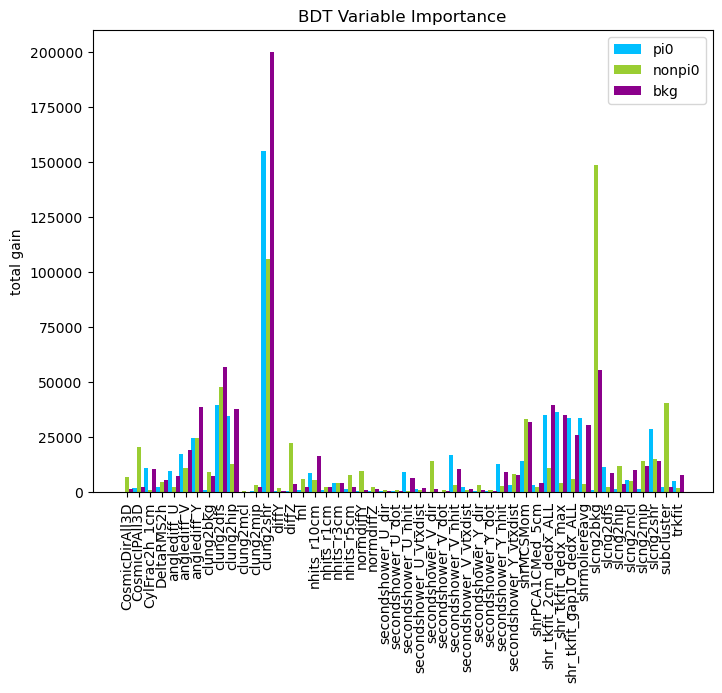

In [16]:
print(gain_imp['pi0'])
print(gain_imp['nonpi0'])
print(gain_imp['bkg'])

if 'shr_tkfit_gap10_dedx_V' in gain_imp['pi0']:
    gain_imp['pi0']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['pi0']['shr_tkfit_gap10_dedx_V']+gain_imp['pi0']['shr_tkfit_gap10_dedx_U']+gain_imp['pi0']['shr_tkfit_gap10_dedx_Y']
    gain_imp['nonpi0']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['nonpi0']['shr_tkfit_gap10_dedx_V']+gain_imp['nonpi0']['shr_tkfit_gap10_dedx_U']+gain_imp['nonpi0']['shr_tkfit_gap10_dedx_Y']
    gain_imp['bkg']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['bkg']['shr_tkfit_gap10_dedx_V']+gain_imp['bkg']['shr_tkfit_gap10_dedx_U']+gain_imp['bkg']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_V']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_U']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_V']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_U']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_V']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_U']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_Y']
if 'shr_tkfit_2cm_dedx_V' in gain_imp['pi0']:
    gain_imp['pi0']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['pi0']['shr_tkfit_2cm_dedx_V']+gain_imp['pi0']['shr_tkfit_2cm_dedx_U']+gain_imp['pi0']['shr_tkfit_2cm_dedx_Y']
    gain_imp['nonpi0']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['nonpi0']['shr_tkfit_2cm_dedx_V']+gain_imp['nonpi0']['shr_tkfit_2cm_dedx_U']+gain_imp['nonpi0']['shr_tkfit_2cm_dedx_Y']
    gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['bkg']['shr_tkfit_2cm_dedx_V']+gain_imp['bkg']['shr_tkfit_2cm_dedx_U']+gain_imp['bkg']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_V']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_U']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_V']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_U']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_V']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_U']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_Y']

print(gain_imp['bkg'])
# print(gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'])

labels = []
pi0_imp = []
nonpi0_imp = []
bkg_imp = []

for i in sorted (gain_imp['pi0'].keys()) :  
    labels.append(i)
    pi0_imp.append(gain_imp['pi0'][i])
    nonpi0_imp.append(gain_imp['nonpi0'][i])
    bkg_imp.append(gain_imp['bkg'][i])
    
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, pi0_imp, width, label='pi0', color='deepskyblue')
rects2 = ax.bar(x, nonpi0_imp, width, label='nonpi0', color='yellowgreen')
rects3 = ax.bar(x + width, bkg_imp, width, label='bkg', color='darkmagenta')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('total gain')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_gain.pdf")
#fig.savefig(ls.plots_path+"bdt_var_gain.pdf")

In [17]:
print(gain_imp['np'])

if 'shr_tkfit_gap10_dedx_V' in gain_imp['np']:
    gain_imp['np']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['np']['shr_tkfit_gap10_dedx_V']+gain_imp['np']['shr_tkfit_gap10_dedx_U']+gain_imp['np']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['np']['shr_tkfit_gap10_dedx_V']
    del gain_imp['np']['shr_tkfit_gap10_dedx_U']
    del gain_imp['np']['shr_tkfit_gap10_dedx_Y']
if 'shr_tkfit_2cm_dedx_V' in gain_imp['np']:
    gain_imp['np']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['np']['shr_tkfit_2cm_dedx_V']+gain_imp['np']['shr_tkfit_2cm_dedx_U']+gain_imp['np']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['np']['shr_tkfit_2cm_dedx_V']
    del gain_imp['np']['shr_tkfit_2cm_dedx_U']
    del gain_imp['np']['shr_tkfit_2cm_dedx_Y']

print(gain_imp['np'])
# print(gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'])

labels = []
np_imp = []

for i in sorted (gain_imp['np'].keys()) :  
    labels.append(i)
    np_imp.append(gain_imp['np'][i])
    
x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects2 = ax.bar(x, np_imp, width, label='np', color='mediumvioletred')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('total gain')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_gain.pdf")
#fig.savefig(ls.plots_path+"bdt_var_gain.pdf")

KeyError: 'np'

{'clung2shr': 48, 'shrMCSMom': 47, 'anglediff_Y': 46, 'shr_tkfit_dedx_max': 45, 'clung2dfs': 44, 'shr_tkfit_gap10_dedx_ALL': 43, 'shrmoliereavg': 42, 'nhits_r10cm': 41, 'slcng2hip': 40, 'shr_tkfit_2cm_dedx_ALL': 39, 'secondshower_V_nhit': 38, 'secondshower_U_nhit': 37, 'anglediff_V': 36, 'secondshower_Y_nhit': 35, 'CylFrac2h_1cm': 34, 'anglediff_U': 33, 'slcng2shr': 32, 'clung2hip': 31, 'trkfit': 30, 'nhits_r5cm': 29, 'nhits_r1cm': 28, 'slcng2dfs': 27, 'DeltaRMS2h': 26, 'secondshower_Y_vtxdist': 25, 'slcng2mcl': 24, 'shrPCA1CMed_5cm': 23, 'subcluster': 22, 'secondshower_U_vtxdist': 21, 'nhits_r3cm': 20, 'secondshower_V_dot': 19, 'secondshower_V_vtxdist': 18, 'clung2bkg': 17, 'slcng2mip': 16, 'secondshower_Y_dir': 15, 'secondshower_U_dir': 14, 'normdiffY': 13, 'secondshower_U_dot': 12, 'fnl': 11, 'secondshower_V_dir': 10, 'CosmicIPAll3D': 9, 'slcng2bkg': 8, 'normdiffZ': 7, 'secondshower_Y_dot': 6, 'diffZ': 5, 'clung2mip': 4, 'diffY': 3, 'clung2mcl': 2, 'CosmicDirAll3D': 1}
{'slcng2hip':

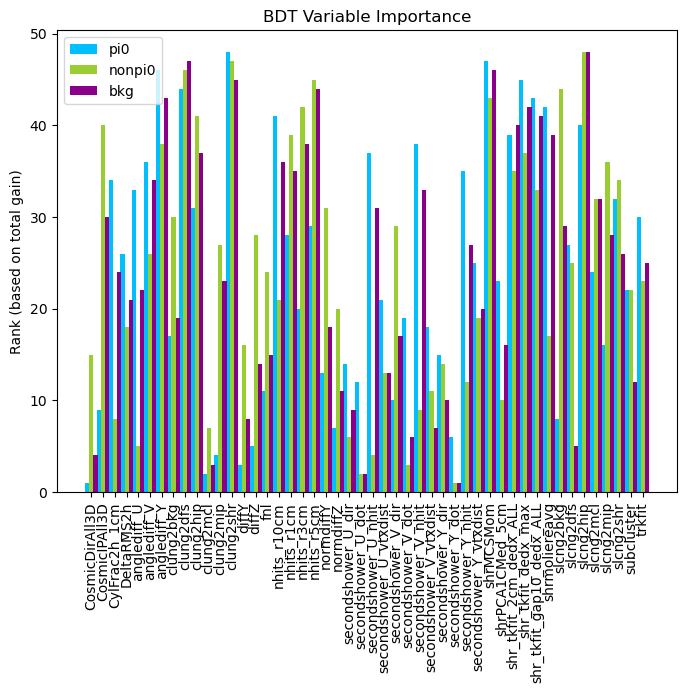

In [ ]:
d_pi0_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['pi0'], key=gain_imp['pi0'].get, reverse=True):
    d_pi0_rnk[w] = rnk
    rnk = rnk-1
print(d_pi0_rnk)

d_nonpi0_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['nonpi0'], key=gain_imp['nonpi0'].get, reverse=True):
    d_nonpi0_rnk[w] = rnk
    rnk = rnk-1
print(d_nonpi0_rnk)

d_bkg_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['bkg'], key=gain_imp['bkg'].get, reverse=True):
    d_bkg_rnk[w] = rnk
    rnk = rnk-1
print(d_bkg_rnk)

pi0_rnk = []
nonpi0_rnk = []
bkg_rnk = []

for i in labels:  
    pi0_rnk.append(d_pi0_rnk[i])
    nonpi0_rnk.append(d_nonpi0_rnk[i])
    bkg_rnk.append(d_bkg_rnk[i])
    
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, pi0_rnk, width, label='pi0', color='deepskyblue')
rects2 = ax.bar(x, nonpi0_rnk, width, label='nonpi0', color='yellowgreen')
rects3 = ax.bar(x + width, bkg_rnk, width, label='bkg', color='darkmagenta')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Rank (based on total gain)')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_rank.pdf")
#fig.savefig(ls.plots_path+"bdt_var_rank.pdf")

In [ ]:
d_np_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['np'], key=gain_imp['np'].get, reverse=True):
    d_np_rnk[w] = rnk
    rnk = rnk-1
print(d_np_rnk)

np_rnk = []

for i in labels:  
    np_rnk.append(d_np_rnk[i])
    
x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, np_rnk, width, label='np', color='cornflowerblue')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Rank (based on total gain)')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_rank.pdf")
#fig.savefig(ls.plots_path+"bdt_var_rank.pdf")

KeyError: 'np'